In [ ]:
#!pip install squarenet

In [ ]:
from squarenet import SquareNet
from squarenet.sampler import samplepoints
from squarenet.utils import to_backend

- sn.fit(x, method = "fast") has native support for Torch tensors or Jax arrays,
- as does sn.map, sn.mapidx,...

- sn.fit with method = "robust" will work as well but can be slow, \
as it will internaly convert the torch/jax tensor in numpy array and \
back at the end as a native torch/jax version hasn't been coded yet

## Backend selection

In [2]:
backend = "jax"

In [4]:
backend = "torch"

In [5]:
if backend == "torch":
    import torch
    device = "cpu"
if backend == "jax":
    import jax
    import jax.numpy as jnp

## ❒ SquareNet for PyTorch

I. sample a dataset \
as a torch tensor, on the device of your choice

In [6]:
I = 100
N = I*I*I
points = samplepoints("ball", size = (N, 3))
points = to_backend(points, backend = "torch", device = device)

type(points)

torch.Tensor

II. Specify backend to the SquareNet

In [7]:
sn = SquareNet(gridshape = (I, I, I), backend = "torch", device = device)
sn.fit(points)

Starting gridification... available method [fast, robust]
selected fast

=== Carthesian sort ===
torch working ...

=== Final Status ===
succesfully sorted at iteration 19


In [8]:
grided_points = sn.map(points)
type(grided_points)

torch.Tensor

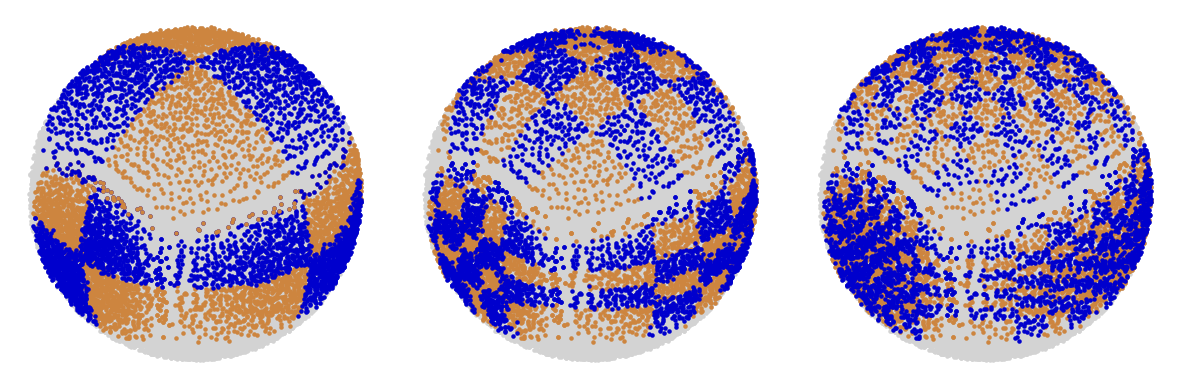

(<Figure size 1200x400 with 3 Axes>, None)

In [9]:
sn.plot(save = False)

## ❒ SquareNet for Jax

In [10]:
I = 100
N = I*I*I
points = samplepoints("ball", size = (N, 3))
points = to_backend(points, backend = "jax")

type(points)

jaxlib._jax.ArrayImpl

In [11]:
sn = SquareNet(gridshape = (I, I, I), backend = "jax")
sn.fit(points)

Starting gridification... available method [fast, robust]
selected fast

=== Carthesian sort ===
jax working ...

=== Final Status ===
succesfully sorted at iteration 18


In [12]:
grided_points = sn.map(points)
type(grided_points)

jaxlib._jax.ArrayImpl

## Jax jiting the fit

In [ ]:
from squarenet.squarenet import jitable_fit, updatenet

In [14]:
max_iter = 500
@jax.jit
def jited_fit(points, grid):
    return jitable_fit(points, grid, max_iter)

I = 100
N = I*I
points = samplepoints("spiky", size = (N, 2))
sn = SquareNet(gridshape = (I, I), backend = "jax")
grid = sn.grid

grid, learning_curve, last_iter = jited_fit(points, grid)
updatenet(sn, points, grid, learning_curve, last_iter)

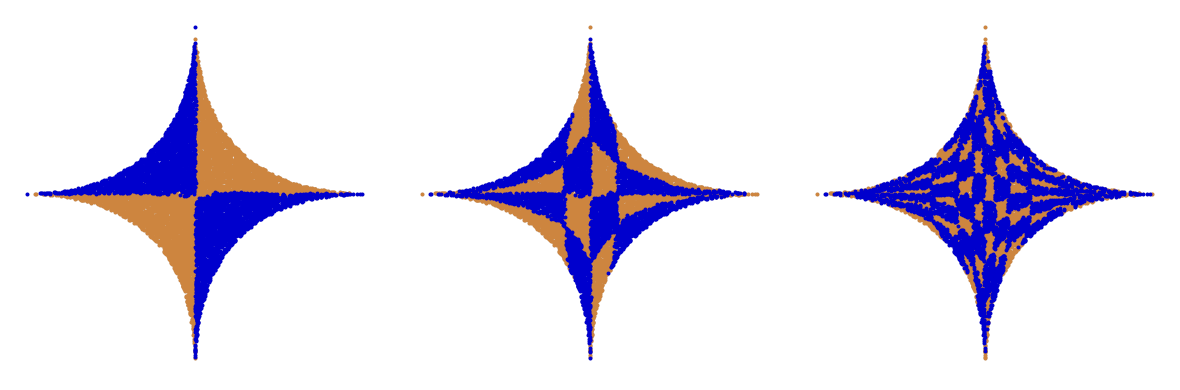

(<Figure size 1200x400 with 3 Axes>, None)

In [15]:
sn.plot(save = False)